<a href="https://colab.research.google.com/github/Sunnik-Chatterjee/AP-Lab/blob/main/2328052_Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

1) Import the dataset "Salaries.csv".

In [3]:
df=pd.read_csv("PANDAS_EXERCISES_Salaries.csv")
df.head(3)

,rank,discipline,phd,service,sex,salary
0,Prof,B,56.0,49,Male,186960.0
1,Prof,A,12.0,6,Male,93000.0
2,Prof,A,23.0,20,Male,110515.0


2) Display how many rows and how many columns and Display first 10
rows and last 15 rows.

In [4]:
print("First 10 rows: ")
df.head(10)

First 10 rows: 


,rank,discipline,phd,service,sex,salary
0,Prof,B,56.0,49,Male,186960.0
1,Prof,A,12.0,6,Male,93000.0
2,Prof,A,23.0,20,Male,110515.0
3,Prof,A,40.0,31,Male,131205.0
4,Prof,B,20.0,18,Male,104800.0
5,Prof,A,20.0,20,Male,122400.0
6,AssocProf,A,20.0,17,Male,81285.0
7,Prof,A,18.0,18,Male,NaN
8,Prof,A,29.0,19,Male,94350.0
9,Prof,A,51.0,51,Male,57800.0


In [5]:
print("Last 15 rows: ")
df.tail(15)

Last 15 rows: 


,rank,discipline,phd,service,sex,salary
63,Prof,A,29.0,27,Female,91000.0
64,AssocProf,A,26.0,24,Female,73300.0
65,Prof,A,36.0,19,Female,117555.0
66,AsstProf,A,7.0,6,Female,63100.0
67,Prof,A,17.0,11,Female,90450.0
68,AsstProf,A,4.0,2,Female,77500.0
69,Prof,A,28.0,7,Female,116450.0
70,AsstProf,A,8.0,3,Female,78500.0
71,AssocProf,B,12.0,9,Female,71065.0
72,Prof,B,24.0,15,Female,161101.0


3) Which Male and Female Professor has the highest and the lowest salaries?

In [22]:
gSex=df.groupby('sex')
print('Male and Female with highest Salary: ')
gSex.max()

Male and Female with highest Salary: 


,rank,discipline,phd,service,salary
sex,,,,,
Female,Prof,B,39.0,36,161101.0
Male,Prof,B,56.0,51,186960.0


In [23]:
print('Male and Female with lowest Salary: ')
gSex.min()

Male and Female with lowest Salary: 


,rank,discipline,phd,service,salary
sex,,,,,
Female,AssocProf,A,2.0,0,62884.0
Male,AssocProf,A,1.0,0,57800.0


4) Which Professor takes the highest and lowest salaries?

In [13]:
print("Teacher with highest Salary: ")
df[df['salary']==df['salary'].max()]

Teacher with highest Salary: 


,rank,discipline,phd,service,sex,salary
0,Prof,B,56.0,49,Male,186960.0


In [14]:
print("Teacher with lowest Salary: ")
df[df['salary']==df['salary'].min()]

Teacher with lowest Salary: 


,rank,discipline,phd,service,sex,salary
9,Prof,A,51.0,51,Male,57800.0


5) Missing ‘Salaries’ - should be replaced as mean of the matching salaries
of those whose ‘ service’ is the same

In [18]:
gService=df.groupby('service')
df['salary']=df['salary'].fillna(gService['salary'].transform("mean"))
df

,rank,discipline,phd,service,sex,salary
0,Prof,B,56.0,49,Male,186960.0
1,Prof,A,12.0,6,Male,93000.0
2,Prof,A,23.0,20,Male,110515.0
3,Prof,A,40.0,31,Male,131205.0
4,Prof,B,20.0,18,Male,104800.0
...,...,...,...,...,...,...
73,Prof,B,18.0,10,Female,105450.0
74,AssocProf,B,19.0,6,Female,104542.0
75,Prof,B,17.0,17,Female,124312.0
76,Prof,A,28.0,14,Female,109954.0


6) Missing ‘phd’ - should be replaced as mean of the matching ‘service’

In [19]:
df['phd']=df['phd'].fillna(gService['phd'].transform('mean'))

7) How many are Male Staff and how many are Female
Staff. Show both in numbers and Graphically using Pie
Chart.

sex
Female    39
Male      39
dtype: int64


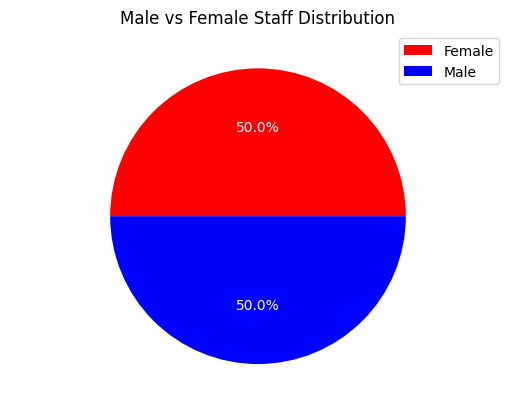

In [67]:
plt.axis('equal')
counts = gSex.size()

print(counts)
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',colors=['r','b'],textprops={'color':'white'})
plt.title("Male vs Female Staff Distribution")
plt.legend()
plt.show()

8) How many are Prof, AssocProf and AsstProf. Show both in numbers and
Graphically using a Pie Chart.

rank
AssocProf    13
AsstProf     19
Prof         46
dtype: int64


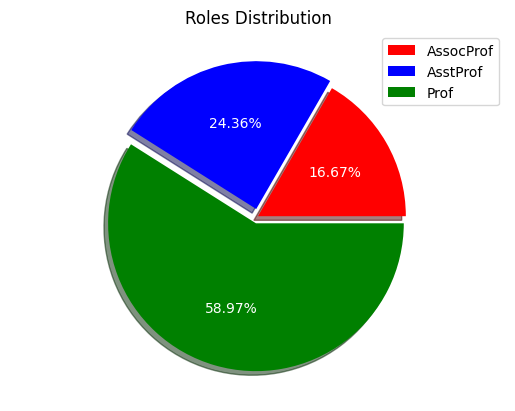

In [64]:
gRank = df.groupby('rank')
count = gRank.size()
print(count)
plt.axis('equal')
plt.pie(
    count,
    labels=count.index,
    shadow=True,
    autopct='%0.2f%%',
    explode=[0,0.05,0.05],
    colors=['red','blue','green'],
    textprops={'color':'white'}
)
plt.title('Roles Distribution')
plt.legend()
plt.show()

9) Who are the senior and junior most employees in the organization.

In [33]:
print("The most senior employee in the organization: ")
df[df['service']==df['service'].max()]

The most senior employee in the organization: 


,rank,discipline,phd,service,sex,salary
9,Prof,A,51.0,51,Male,57800.0


In [34]:
print("The most junior employee in the organization: ")
df[df['service']==df['service'].min()]

The most junior employee in the organization: 


,rank,discipline,phd,service,sex,salary
12,AsstProf,B,1.0,0,Male,88000.0
17,AsstProf,B,4.0,0,Male,92000.0
23,AsstProf,A,2.0,0,Male,85000.0
43,AsstProf,B,5.0,0,Female,77000.0
52,Prof,A,12.0,0,Female,105000.0
55,AsstProf,A,2.0,0,Female,72500.0


10) Draw a histogram of the salaries divided into bin starting from 50K and
increment of 15K

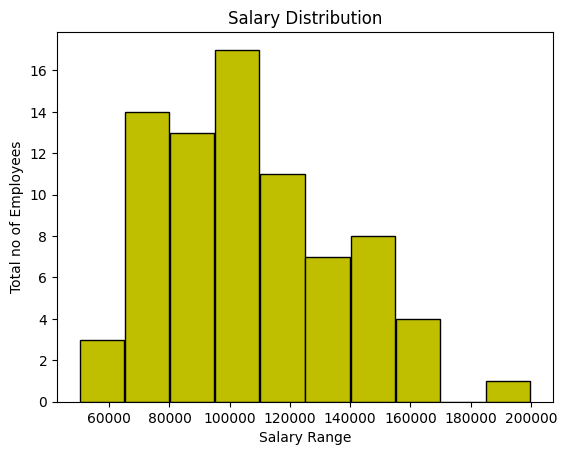

In [65]:
start=50000
bin_width=15000
end=df['salary'].max()
bins=np.arange(start,end+bin_width,bin_width)
plt.hist(df['salary'], bins=bins,rwidth=0.98,edgecolor='black',color='y')
plt.xlabel("Salary Range")
plt.ylabel('Total no of Employees')
plt.title('Salary Distribution')
plt.show()